# Step 3.1: Train the Baseline Autoencoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import MinMaxScaler

# Load preprocessed profiling (normal) data
X_train = np.load("/content/drive/MyDrive/zeroday_detection/data/embeddings_normal_v2.npy")

# Rescale the input data to the range [0, 1] using MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)

# Define Autoencoder architecture
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dense(16, activation='relu')(encoded)  # Bottleneck layer

decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(decoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Train the model
history = autoencoder.fit(
    X_train, X_train,  # Input and output are the same for autoencoders
    epochs=20,
    batch_size=64,
    validation_split=0.3
)

# Save model for later evaluation
autoencoder.save("/content/drive/MyDrive/zeroday_detection/models/autoencoder_baseline_m3_d64_v2.keras")


Epoch 1/20
4266/4266 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 0.0130 - val_loss: 9.4332e-04
Epoch 2/20
4266/4266 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 2.7908e-04 - val_loss: 5.6930e-04
Epoch 3/20
4266/4266 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 1.5323e-04 - val_loss: 4.3146e-04
Epoch 4/20
4266/4266 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 1.0711e-04 - val_loss: 3.7049e-04
Epoch 5/20
4266/4266 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 9.0385e-05 - val_loss: 3.3667e-04
Epoch 6/20
4266/4266 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 7.9870e-05 - val_loss: 3.0347e-04
Epoch 7/20
4266/4266 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 6.6097e-05 - val_loss: 2.7387e-04
Epoch 8/20
4266/4266 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 6.0165e-05 - val_loss: 2.7723e-04
Epoch 9/20
4266/4266 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 5.5889e-05 - val_loss: 2.4880e-04
Epoch 10/20
4266/4266 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 5.2055e-05 - val_loss: 2.5177e-04
Epoch 11/20
4266/4266 ━━━━━━━━━━━

# Step 3.2: Evaluate Reconstruction Errors

12187/12187 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step
50444/50444 ━━━━━━━━━━━━━━━━━━━━ 78s 2ms/step


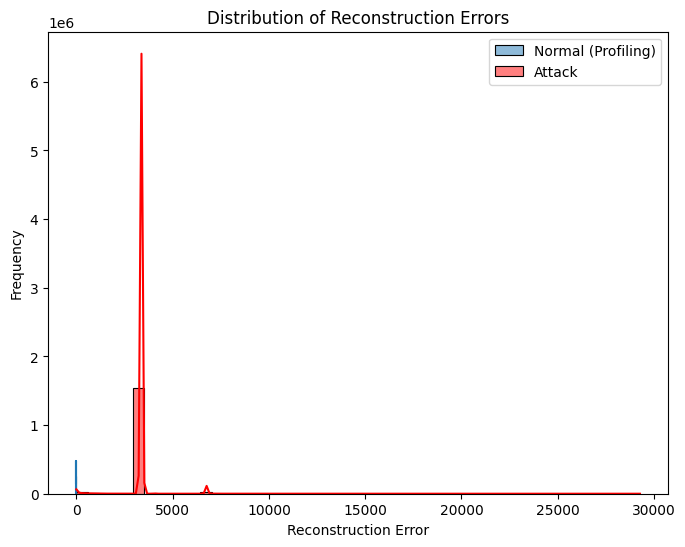

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load attack data
X_attack = np.load("/content/drive/MyDrive/zeroday_detection/data/embeddings_attack_v2.npy")

# Load trained autoencoder
autoencoder = tf.keras.models.load_model("/content/drive/MyDrive/zeroday_detection/models/autoencoder_baseline_m3_d64_v2.keras")

# Compute reconstruction errors
def compute_reconstruction_errors(model, data):
    reconstructions = model.predict(data)
    errors = np.mean(np.abs(reconstructions - data), axis=1)
    return errors

recon_errors_profiling = compute_reconstruction_errors(autoencoder, X_train)
recon_errors_attack = compute_reconstruction_errors(autoencoder, X_attack)

# Plot histograms of reconstruction errors
plt.figure(figsize=(8,6))
sns.histplot(recon_errors_profiling, bins=50, kde=True, label="Normal (Profiling)")
sns.histplot(recon_errors_attack, bins=50, kde=True, color="r", label="Attack")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Reconstruction Errors")
plt.legend()
plt.show()


In [ ]:
# Tester plusieurs seuils (90%, 95%, 99%)
percentiles = [90, 95, 99]
for p in percentiles:
    seuil = np.percentile(recon_errors_profiling, p)
    print(f"Seuil pour le {p}e percentile : {seuil}")


Seuil pour le 90e percentile : 0.007540887221693993
Seuil pour le 95e percentile : 0.010832667350769043
Seuil pour le 99e percentile : 0.01845698244869709


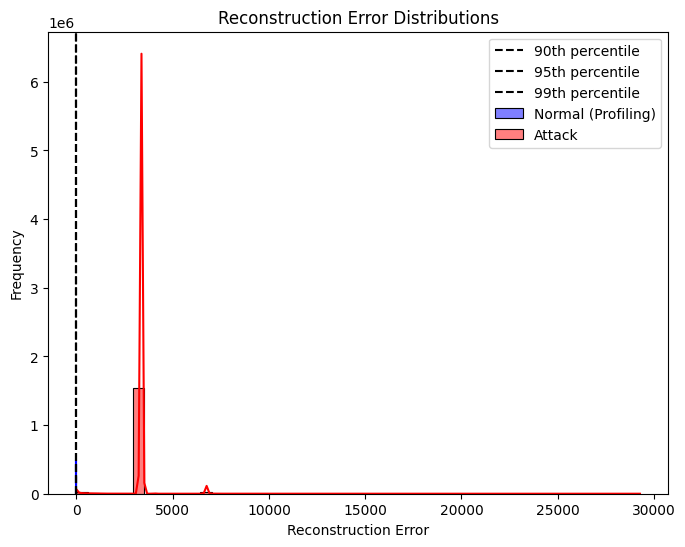

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distributions
plt.figure(figsize=(8,6))
sns.histplot(recon_errors_profiling, bins=50, kde=True, label="Normal (Profiling)", color='blue')
sns.histplot(recon_errors_attack, bins=50, kde=True, label="Attack", color='red')

# Add threshold lines
for p in [90, 95, 99]:
    seuil = np.percentile(recon_errors_profiling, p)
    plt.axvline(seuil, color='black', linestyle='--', label=f"{p}th percentile")

plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Reconstruction Error Distributions")
plt.legend()
plt.show()


In [ ]:
threshold = np.percentile(recon_errors_profiling, 95)
print("Chosen threshold (95th percentile):", threshold)


Chosen threshold (95th percentile): 0.024975633


# Step 3.4: Compute Anomaly Predictions


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Convert errors into anomaly predictions
y_true = np.concatenate([np.zeros(len(recon_errors_profiling)), np.ones(len(recon_errors_attack))])  # 0 = normal, 1 = attack
y_pred = np.concatenate([
    recon_errors_profiling > threshold,
    recon_errors_attack > threshold
])

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Compute classification report (precision, recall, F1-score)
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=["Normal", "Attaque"]))


Confusion Matrix:
 [[ 370458   19498]
 [      0 1614182]]
Classification Report:
               precision    recall  f1-score   support

      Normal       1.00      0.95      0.97    389956
     Attaque       0.99      1.00      0.99   1614182

    accuracy                           0.99   2004138
   macro avg       0.99      0.97      0.98   2004138
weighted avg       0.99      0.99      0.99   2004138



Confusion Matrix:
[[ 370458   19498]
 [      0 1614182]]
F1 Score: 0.9939966661145085
AUC: 0.974999743560812


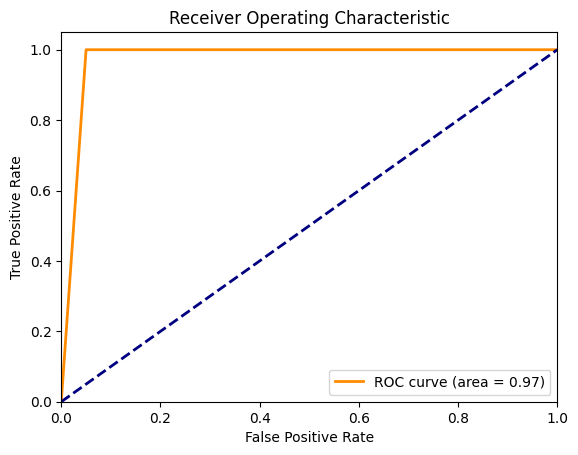


Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97    389956
         1.0       0.99      1.00      0.99   1614182

    accuracy                           0.99   2004138
   macro avg       0.99      0.97      0.98   2004138
weighted avg       0.99      0.99      0.99   2004138



In [ ]:
from sklearn.metrics import confusion_matrix,f1_score, classification_report


# Convert errors into anomaly predictions
y_true = np.concatenate([np.zeros(len(recon_errors_profiling)), np.ones(len(recon_errors_attack))])  # 0 = normal, 1 = attack
y_pred = np.concatenate([
    recon_errors_profiling > threshold,
    recon_errors_attack > threshold
])


# Confusion Matrix
cm = confusion_matrix(y_true, y_pred.round())  # round predictions to 0 or 1
print("Confusion Matrix:")
print(cm)

# F1 Score
f1 = f1_score(y_true, y_pred.round())
print(f"F1 Score: {f1}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc}")

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred.round()))

In [ ]:
# After computing reconstruction errors in Module 3
np.save("/content/drive/MyDrive/zeroday_detection/data/recon_errors_profiling_m3_v2.npy", recon_errors_profiling)
np.save("/content/drive/MyDrive/zeroday_detection/data/recon_errors_attack_m3_v2.npy", recon_errors_attack)
